ODE:
$$\frac{dy(t)}{dt} + 0.05 y(t) = 0.2F(t), \qquad y(0) = 3.1$$
Where $F(t)$ is Real GDP data and $y(t)$ represents capital stock.

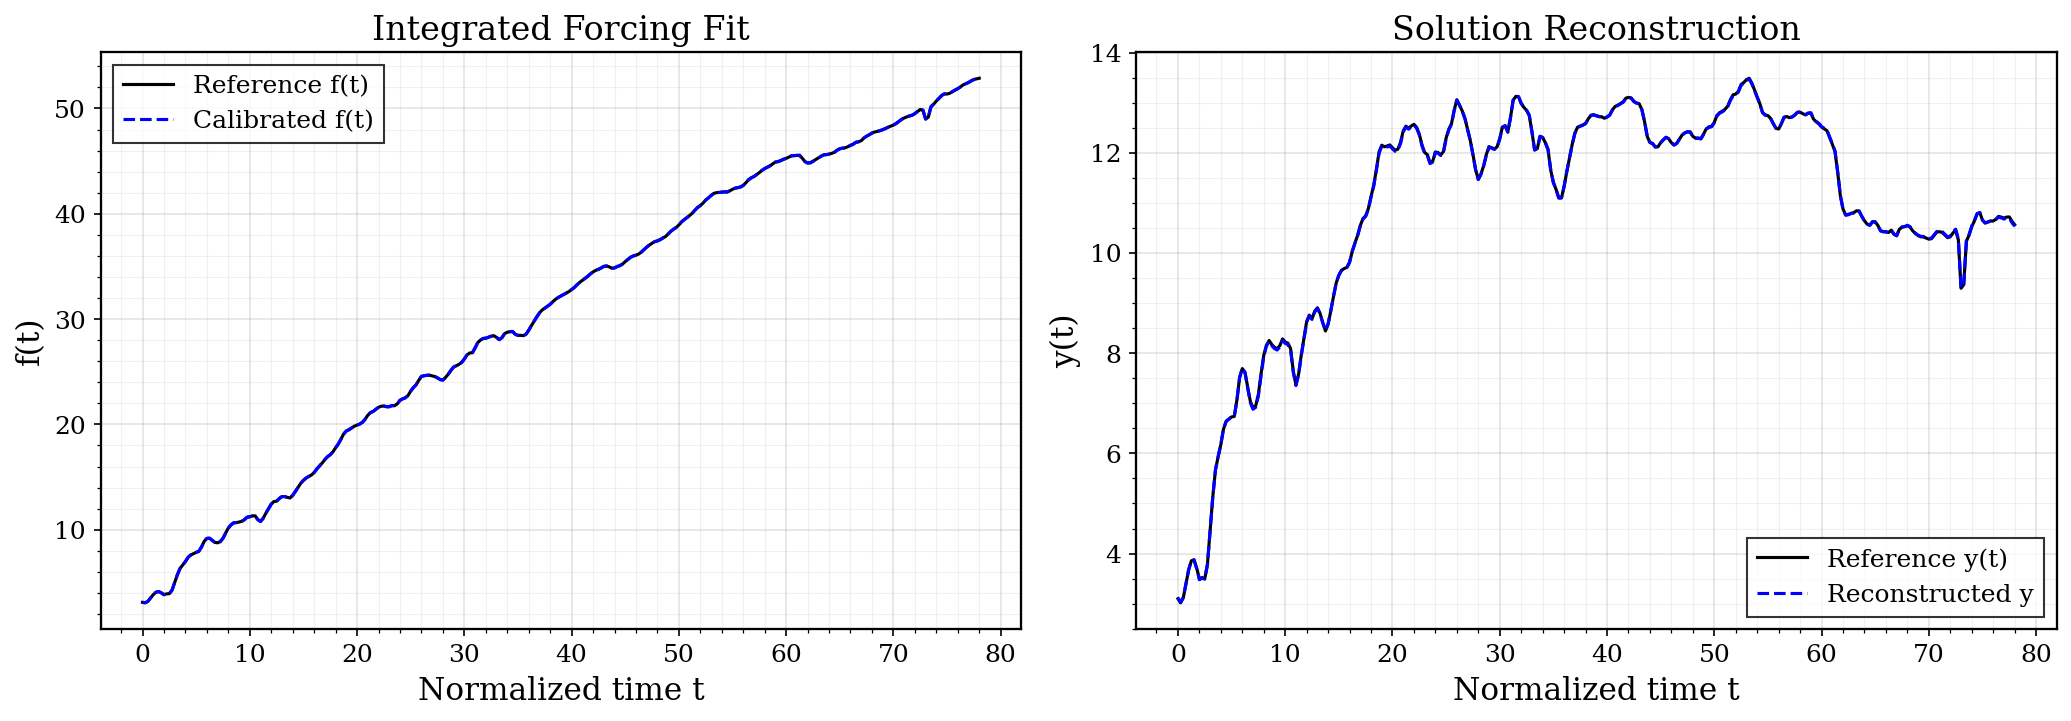


Full-Batch Relative MSE Summary
Quantity                     Non-Branched
-------------------------------------------
Forcing f(t)                 6.593474e-08 
Solution y(t)                1.186867e-06 


In [6]:
import pandas as pd
import signatory
import numpy as np
import matplotlib.pyplot as plt
import torch

torch.set_default_dtype(torch.float64)

def trapezoidal_array(F_vals, dt):
    integrated = [0.0]
    total = 0.0
    for i in range(1, len(F_vals)):
        trap = (F_vals[i - 1] + F_vals[i]) / 2
        total += trap * dt
        integrated.append(total)
    return integrated


def trapezoidal_cols(M, dt):
    trap = (M[:-1] + M[1:]) / 2 * dt
    out = torch.zeros_like(M)
    out[1:] = torch.cumsum(trap, dim=0)
    return out


def signature_of_path(path, depth=3):
    if not isinstance(path, torch.Tensor):
        path = torch.tensor(path, dtype=torch.float64)
    path_tensor = path.unsqueeze(0)
    sig = signatory.signature(
        path_tensor,
        depth=depth,
        basepoint=path_tensor[:, 0, :],
        scalar_term=True
    ).squeeze(0)
    return sig.detach()


def interpolate_to_grid(t_source, y_source, t_target):
    idx = torch.searchsorted(t_source.contiguous(), t_target.contiguous())
    idx = idx.clamp(1, len(t_source) - 1)
    t0 = t_source[idx - 1]
    t1 = t_source[idx]
    y0 = y_source[idx - 1]
    y1 = y_source[idx]
    weight = (t_target - t0) / (t1 - t0)
    return y0 + weight * (y1 - y0)


def set_professional_plot_style():
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 13,
        "axes.labelsize": 15,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.linewidth": 1.1,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    })


def format_axes(ax):
    ax.grid(True, which="major", alpha=0.35, linewidth=0.8)
    ax.grid(True, which="minor", alpha=0.18, linewidth=0.5)
    ax.minorticks_on()
    ax.legend(frameon=True, fancybox=False, edgecolor="black", loc="best")
    for spine in ax.spines.values():
        spine.set_linewidth(1.1)


# Load Data

df = pd.read_csv("econ_f_t_gdp_normalized_time.csv")
df["t"] = pd.to_datetime(df["t"])

t_forcing = df["t_norm"]
F_vals_original = 0.2 * df["f"]
dt_original = t_forcing[1] - t_forcing[0]
F_star_original = trapezoidal_array(F_vals_original, dt_original)

sol = pd.read_csv("sollow_ode_solution.csv")
t_true = sol["t"].values

forcing_data = pd.read_csv("integrated_f.csv")
t_vals_f = forcing_data["t_norm"].to_numpy(dtype=np.float64)
f_vals_f = forcing_data["f_integrated"].to_numpy(dtype=np.float64)

t_vals_f_tensor = torch.tensor(t_vals_f, dtype=torch.float64)
f_vals_f_tensor = torch.tensor(f_vals_f, dtype=torch.float64)

fullpath = torch.stack((t_vals_f_tensor, f_vals_f_tensor), dim=1)

num_partitions = len(fullpath)
total_points = len(fullpath)
partition_size = total_points // num_partitions

t_vals = t_vals_f_tensor
dt = float((t_vals[1] - t_vals[0]).item())
N = len(t_vals)


# Path Construction 

paths_nb = []  

for i in range(num_partitions):
    end_index = (i + 1) * partition_size
    if i == num_partitions - 1:
        end_index = total_points

    path_nb = []
    for j in range(end_index):
        t_val = forcing_data.iloc[j, 0]
        f_val = forcing_data.iloc[j, 1]
        ta1 = np.power(t_val, 1)
        path_nb.append([ta1, f_val])

    paths_nb.append(path_nb)


# Parameters

signature_level = 3
lambda_econ = 0.05
n0 = 50
retrain_every = 10


# Full Batch 

path_tensor_nb = torch.tensor(np.array(paths_nb[-1]), dtype=torch.float64).unsqueeze(0)
sigs_nb = signatory.signature(
    path_tensor_nb, stream=True, depth=signature_level,
    basepoint=path_tensor_nb[:, 0, :], scalar_term=True
).squeeze(0).detach().numpy()
S_nb = sigs_nb
N_full = len(S_nb)

K_nb = np.zeros((N_full, N_full), dtype=np.float64)
K1_nb = np.zeros((N_full, N_full), dtype=np.float64)
for i in range(N_full):
    for j in range(N_full):
        K_nb[i, j] = np.dot(S_nb[i], S_nb[j])
for j in range(N_full):
    col = K_nb[:, j]
    integrated = trapezoidal_array(col, dt)
    for i in range(N_full):
        K1_nb[i, j] = integrated[i]

integrated_f = pd.read_csv("integrated_f.csv")
F_star = integrated_f["f_integrated"].to_numpy(dtype=np.float64)

Psi_nb = K_nb + lambda_econ * K1_nb
A_nb = np.linalg.lstsq(Psi_nb, F_star, rcond=None)[0]
F_hat_nb = Psi_nb @ A_nb
K_A_nb   = K_nb @ A_nb

# Solow Solution

df_solow = pd.read_csv("sollow_ode_solution.csv")
time_col = df_solow.columns[0]
y_col    = df_solow.columns[-1]
t_solow  = np.asarray(df_solow[time_col], dtype=float)
y_solow  = np.asarray(df_solow[y_col],   dtype=float)

time_plot = t_vals_f
y_solow_interp_full = np.interp(time_plot, t_solow, y_solow)


# Plot 1 — 1x2: Forcing Fit & Solution Reconstruction

set_professional_plot_style()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Forcing fit
axes[0].plot(time_plot, F_star,   color="black", linewidth=1.5, label="Reference f(t)")
axes[0].plot(time_plot, F_hat_nb, color="blue",   linestyle="--", linewidth=1.5, label="Calibrated f(t)")
axes[0].set_title("Integrated Forcing Fit")
axes[0].set_xlabel("Normalized time t")
axes[0].set_ylabel("f(t)")
format_axes(axes[0])

# Right: Solution reconstruction
axes[1].plot(time_plot, y_solow_interp_full, color="black", linewidth=1.5, label="Reference y(t)")
axes[1].plot(time_plot, K_A_nb,              color="blue",   linestyle="--", linewidth=1.5, label="Reconstructed y")
axes[1].set_title("Solution Reconstruction")
axes[1].set_xlabel("Normalized time t")
axes[1].set_ylabel("y(t)")
format_axes(axes[1])

fig.tight_layout()
plt.show()

#Relative MSE — Forcing and Solution

def rel_mse_np(pred, true):
    pred = np.asarray(pred, dtype=np.float64)
    true = np.asarray(true, dtype=np.float64)
    return np.mean((pred - true) ** 2) / np.mean(true ** 2)

def pct_imp(nb, b):
    return (nb - b) / abs(nb) * 100 if nb != 0 else np.nan


# Forcing relative MSE
rel_mse_F_nb = rel_mse_np(F_hat_nb, F_star)

# Solution relative MSE
rel_mse_y_nb = rel_mse_np(K_A_nb, y_solow_interp_full)


print("\n" + "=" * 43)
print("Full-Batch Relative MSE Summary")
print("=" * 43)
print(f"{'Quantity':25s} {'Non-Branched':>15s}")
print("-" * 43)

print(
    f"{'Forcing f(t)':25s} "
    f"{rel_mse_F_nb:>15.6e} "
)

print(
    f"{'Solution y(t)':25s} "
    f"{rel_mse_y_nb:>15.6e} "
)

print("=" * 43)

NON-BRANCHED TRAINING DONE.
Running non-branched rolling prediction...
[Retrain] at index 60
[Retrain] at index 70
[Retrain] at index 80
[Retrain] at index 90
[Retrain] at index 100
[Retrain] at index 110
[Retrain] at index 120
[Retrain] at index 130
[Retrain] at index 140
[Retrain] at index 150
[Retrain] at index 160
[Retrain] at index 170
[Retrain] at index 180
[Retrain] at index 190
[Retrain] at index 200
[Retrain] at index 210
[Retrain] at index 220
[Retrain] at index 230
[Retrain] at index 240
[Retrain] at index 250
[Retrain] at index 260
[Retrain] at index 270
[Retrain] at index 280
[Retrain] at index 290
[Retrain] at index 300
[Retrain] at index 310
NON-BRANCHED PREDICTION DONE.

Non-Branched Error Summary
Quantity                                 MSE       Relative MSE     Relative MSE (%)
--------------------------------------------------------------------------------------
Training forcing                1.245004e-04       1.636290e-06              0.0002%
Training solution   

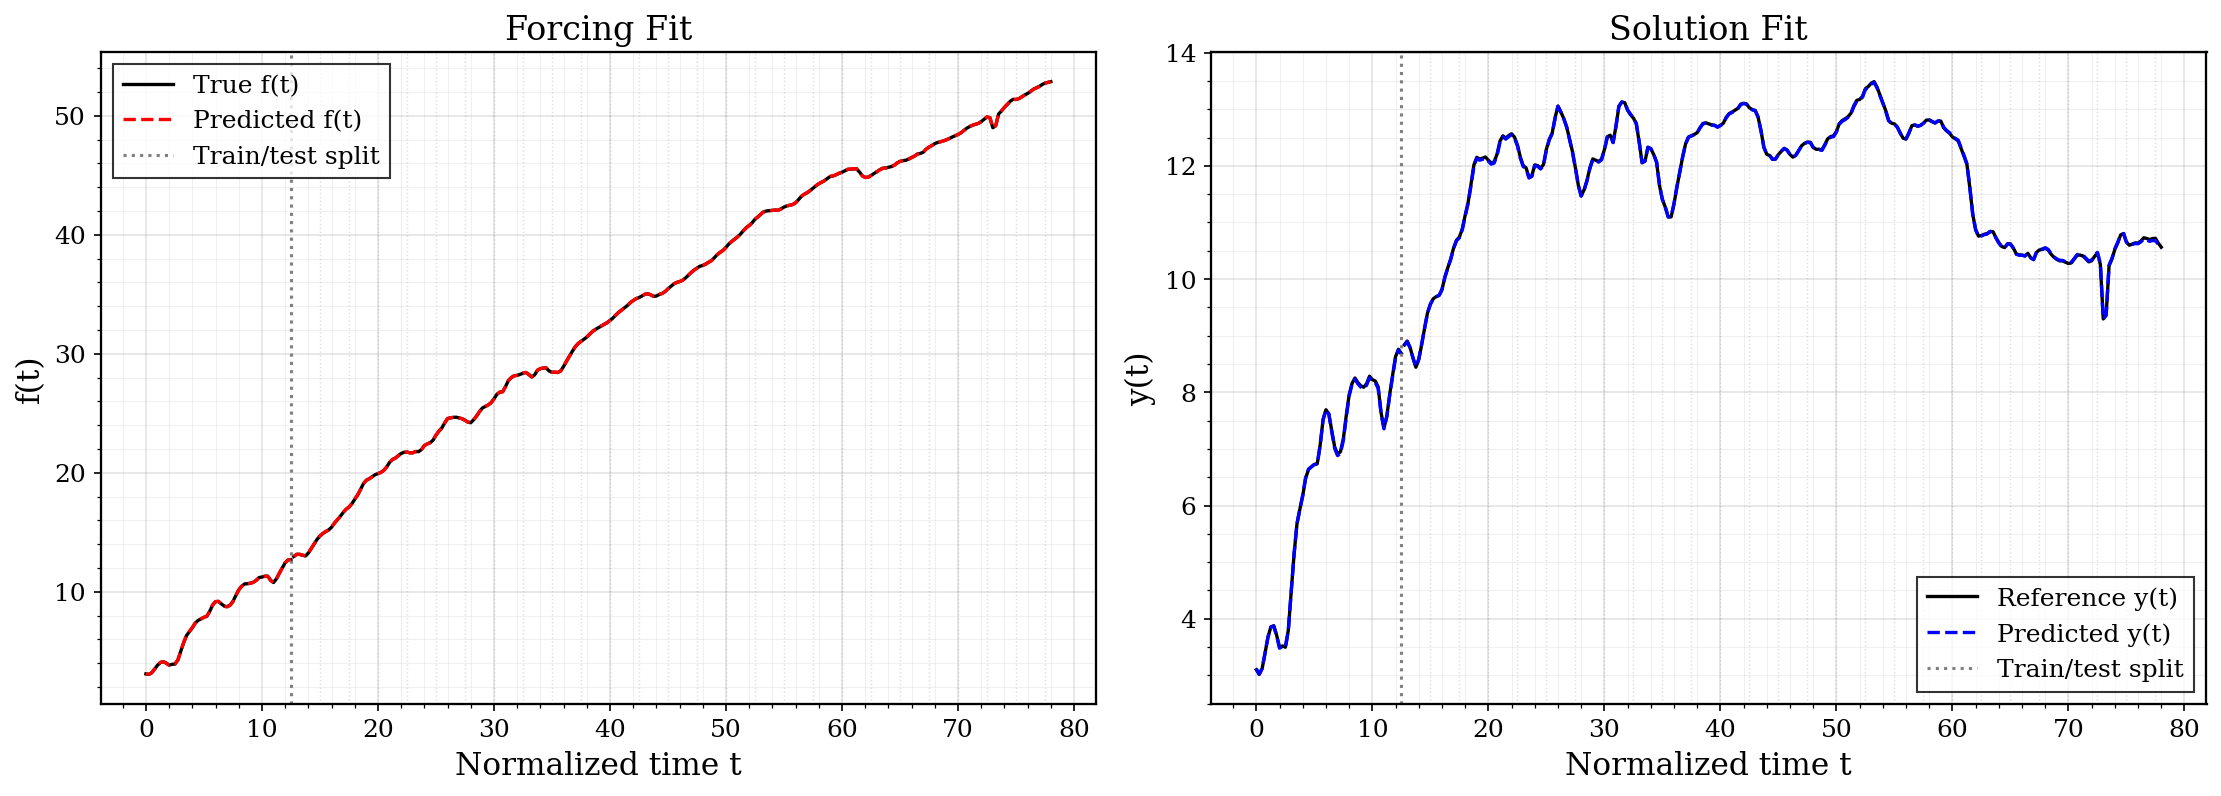

In [7]:
# Rolling Retrain Setup — non-branched only

F_star_torch  = torch.tensor(F_star,  dtype=torch.float64)
t_solow_torch = torch.tensor(t_solow, dtype=torch.float64)
y_solow_torch = torch.tensor(y_solow, dtype=torch.float64)

if len(y_solow_torch) != len(t_vals) or not torch.allclose(t_solow_torch, t_vals):
    y_true_interp = interpolate_to_grid(t_solow_torch, y_solow_torch, t_vals)
else:
    y_true_interp = y_solow_torch.clone()


def build_state_nonbranched(paths_nb, n0, signature_level, lambda_econ, dt, t_vals,
                            F_star_torch, y_true_interp):
    S0_raw = torch.stack([
        signature_of_path(paths_nb[i], depth=signature_level)
        for i in range(n0 + 1)
    ])

    K0 = S0_raw @ S0_raw.T
    K1_0 = trapezoidal_cols(K0, dt)

    Psi0 = K0 + lambda_econ * K1_0

    rcond = torch.finfo(torch.float64).eps
    alpha0 = torch.linalg.lstsq(
        Psi0,
        F_star_torch[:n0 + 1],
        rcond=rcond,
        driver="gelsd"
    ).solution

    F_pred_train = Psi0 @ alpha0
    y_pred_train = K0 @ alpha0

    return {
        "lambda_econ": lambda_econ,
        "dt": dt,
        "n0": n0,
        "N": len(t_vals),
        "paths": paths_nb,
        "signature_level": signature_level,
        "F_star": F_star_torch,
        "t_vals": t_vals,
        "y_true_interp": y_true_interp,
        "alpha0": alpha0,
        "S_hist": S0_raw.clone(),
        "K_prev": K0[n0, :].clone(),
        "I1": K1_0[n0, :].clone(),
        "F_pred_train": F_pred_train,
        "y_pred_train": y_pred_train,
    }


state_nb = build_state_nonbranched(
    paths_nb=paths_nb,
    n0=n0,
    signature_level=signature_level,
    lambda_econ=lambda_econ,
    dt=dt,
    t_vals=t_vals,
    F_star_torch=F_star_torch,
    y_true_interp=y_true_interp
)

print("NON-BRANCHED TRAINING DONE.")


# Rolling Online Prediction — non-branched 

def rolling_online_predict_econ_nonbranched(state, retrain_every=5, max_steps=None):
    lambda_econ = state["lambda_econ"]
    dt = state["dt"]
    n0 = state["n0"]
    N = state["N"]
    paths = state["paths"]
    depth = state["signature_level"]
    F_star = state["F_star"]

    if max_steps is None:
        end_idx = N - 1
    else:
        end_idx = min(N - 1, n0 + max_steps)

    S_hist = state["S_hist"].clone()

    alphas = torch.zeros(end_idx + 1, dtype=torch.float64)
    alphas[:n0 + 1] = state["alpha0"]

    K_prev = state["K_prev"].clone()
    I1 = state["I1"].clone()

    F_pred = torch.zeros(end_idx + 1, dtype=torch.float64)
    y_pred = torch.zeros(end_idx + 1, dtype=torch.float64)

    F_pred[:n0 + 1] = state["F_pred_train"]
    y_pred[:n0 + 1] = state["y_pred_train"]

    retrain_indices = []

    eps = 1e-3

    for i in range(n0 + 1, end_idx + 1):

        s_new = signature_of_path(paths[i], depth=depth)

        k_row_old = S_hist @ s_new
        k_ii = torch.dot(s_new, s_new)

        I1_new = I1 + 0.5 * (K_prev + k_row_old) * dt
        I1 = I1_new
        K_prev = k_row_old

        col_i = torch.cat([
            k_row_old,
            torch.tensor([k_ii.item()], dtype=torch.float64)
        ])

        inner_i = trapezoidal_cols(col_i, dt)
        I1_i = inner_i[-1]

        I1 = torch.cat([
            I1,
            torch.tensor([I1_i.item()], dtype=torch.float64)
        ])

        K_prev = torch.cat([
            K_prev,
            torch.tensor([k_ii.item()], dtype=torch.float64)
        ])

        psi_row_old = k_row_old + lambda_econ * I1[:i]
        psi_diag = k_ii + lambda_econ * I1[i]

        residual = F_star[i] - torch.dot(psi_row_old, alphas[:i])
        alphas[i] = residual / (psi_diag + eps)

        F_pred[i] = torch.dot(psi_row_old, alphas[:i]) + psi_diag * alphas[i]
        y_pred[i] = torch.dot(k_row_old, alphas[:i]) + k_ii * alphas[i]

        S_hist = torch.vstack([S_hist, s_new.unsqueeze(0)])

        if (i - n0) % retrain_every == 0:
            print(f"[Retrain] at index {i}")
            retrain_indices.append(i)

            K = S_hist @ S_hist.T
            K1 = trapezoidal_cols(K, dt)
            Psi = K + lambda_econ * K1

            Psi_block = Psi[:i + 1, :i + 1]
            F_block = F_star[:i + 1]

            scale = torch.mean(torch.diag(Psi_block))
            lam = 1e-13 * scale
            I_mat = torch.eye(i + 1, dtype=torch.float64)

            alphas[:i + 1] = torch.linalg.solve(
                Psi_block + lam * I_mat,
                F_block
            )

            F_pred[:i + 1] = Psi_block @ alphas[:i + 1]
            y_pred[:i + 1] = K @ alphas[:i + 1]

    return {
        "F_pred": F_pred,
        "y_pred": y_pred,
        "alphas": alphas,
        "retrain_indices": retrain_indices,
        "end_idx": end_idx,
    }


print("Running non-branched rolling prediction...")
res_nb = rolling_online_predict_econ_nonbranched(
    state_nb,
    retrain_every=retrain_every
)

print("NON-BRANCHED PREDICTION DONE.")


def mse_torch(pred, true):
    return torch.mean((pred - true) ** 2).item()


def rel_mse_torch(pred, true):
    return torch.mean((pred - true) ** 2).item() / torch.mean(true ** 2).item()


idx_train = torch.arange(0, n0 + 1)
idx_test = torch.arange(n0 + 1, res_nb["end_idx"] + 1)
idx_full = torch.arange(0, res_nb["end_idx"] + 1)

# Training errors
mse_train_F = mse_torch(res_nb["F_pred"][idx_train], F_star_torch[idx_train])
rel_mse_train_F = rel_mse_torch(res_nb["F_pred"][idx_train], F_star_torch[idx_train])

mse_train_y = mse_torch(res_nb["y_pred"][idx_train], y_true_interp[idx_train])
rel_mse_train_y = rel_mse_torch(res_nb["y_pred"][idx_train], y_true_interp[idx_train])

# Testing errors
mse_test_F = mse_torch(res_nb["F_pred"][idx_test], F_star_torch[idx_test])
rel_mse_test_F = rel_mse_torch(res_nb["F_pred"][idx_test], F_star_torch[idx_test])

mse_test_y = mse_torch(res_nb["y_pred"][idx_test], y_true_interp[idx_test])
rel_mse_test_y = rel_mse_torch(res_nb["y_pred"][idx_test], y_true_interp[idx_test])

# Full prediction errors
mse_full_F = mse_torch(res_nb["F_pred"][idx_full], F_star_torch[idx_full])
rel_mse_full_F = rel_mse_torch(res_nb["F_pred"][idx_full], F_star_torch[idx_full])

mse_full_y = mse_torch(res_nb["y_pred"][idx_full], y_true_interp[idx_full])
rel_mse_full_y = rel_mse_torch(res_nb["y_pred"][idx_full], y_true_interp[idx_full])


print("\n" + "=" * 86)
print("Non-Branched Error Summary")
print("=" * 86)
print(f"{'Quantity':25s} {'MSE':>18s} {'Relative MSE':>18s} {'Relative MSE (%)':>20s}")
print("-" * 86)

print(f"{'Training forcing':25s} {mse_train_F:>18.6e} {rel_mse_train_F:>18.6e} {100 * rel_mse_train_F:>19.4f}%")
print(f"{'Training solution':25s} {mse_train_y:>18.6e} {rel_mse_train_y:>18.6e} {100 * rel_mse_train_y:>19.4f}%")

print(f"{'Testing forcing':25s} {mse_test_F:>18.6e} {rel_mse_test_F:>18.6e} {100 * rel_mse_test_F:>19.4f}%")
print(f"{'Testing solution':25s} {mse_test_y:>18.6e} {rel_mse_test_y:>18.6e} {100 * rel_mse_test_y:>19.4f}%")

print(f"{'Full forcing':25s} {mse_full_F:>18.6e} {rel_mse_full_F:>18.6e} {100 * rel_mse_full_F:>19.4f}%")
print(f"{'Full solution':25s} {mse_full_y:>18.6e} {rel_mse_full_y:>18.6e} {100 * rel_mse_full_y:>19.4f}%")

print("=" * 86)


set_professional_plot_style()

t_train = t_vals[idx_train]
t_test = t_vals[idx_test]
t_split = float(t_vals[n0].item())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharex=True)



ax = axes[0]

# True forcing
ax.plot(
    t_train.tolist(),
    F_star_torch[idx_train].tolist(),
    color="black",
    linewidth=1.6,
    label="True f(t)"
)
ax.plot(
    t_test.tolist(),
    F_star_torch[idx_test].tolist(),
    color="black",
    linewidth=1.6
)

# Predicted forcing
ax.plot(
    t_train.tolist(),
    res_nb["F_pred"][idx_train].tolist(),
    color="red",
    linestyle="--",
    linewidth=1.6,
    label="Predicted f(t)"
)
ax.plot(
    t_test.tolist(),
    res_nb["F_pred"][idx_test].tolist(),
    color="red",
    linestyle="--",
    linewidth=1.6
)

# Train/test split
ax.axvline(
    x=t_split,
    color="gray",
    linestyle=":",
    linewidth=1.5,
    label="Train/test split"
)

# Retrain markers
for r_idx in res_nb["retrain_indices"]:
    ax.axvline(
        x=float(t_vals[r_idx].item()),
        color="gray",
        linestyle=":",
        linewidth=0.7,
        alpha=0.25
    )

ax.set_title("Forcing Fit")
ax.set_xlabel("Normalized time t")
ax.set_ylabel("f(t)")
format_axes(ax)

ax = axes[1]

# True solution
ax.plot(
    t_train.tolist(),
    y_true_interp[idx_train].tolist(),
    color="black",
    linewidth=1.6,
    label="Reference y(t)"
)
ax.plot(
    t_test.tolist(),
    y_true_interp[idx_test].tolist(),
    color="black",
    linewidth=1.6
)

# Predicted solution
ax.plot(
    t_train.tolist(),
    res_nb["y_pred"][idx_train].tolist(),
    color="blue",
    linestyle="--",
    linewidth=1.6,
    label="Predicted y(t)"
)
ax.plot(
    t_test.tolist(),
    res_nb["y_pred"][idx_test].tolist(),
    color="blue",
    linestyle="--",
    linewidth=1.6
)

# Train/test split
ax.axvline(
    x=t_split,
    color="gray",
    linestyle=":",
    linewidth=1.5,
    label="Train/test split"
)

# Retrain markers
for r_idx in res_nb["retrain_indices"]:
    ax.axvline(
        x=float(t_vals[r_idx].item()),
        color="gray",
        linestyle=":",
        linewidth=0.7,
        alpha=0.25
    )

ax.set_title("Solution Fit")
ax.set_xlabel("Normalized time t")
ax.set_ylabel("y(t)")
format_axes(ax)


fig.tight_layout()
plt.show()

In [8]:
# Relative MSE Summary — Non-Branched

def rel_mse_torch(pred, true):
    """
    Relative MSE:
        mean((pred - true)^2) / mean(true^2)
    """
    return torch.mean((pred - true) ** 2).item() / torch.mean(true ** 2).item()


idx_train = torch.arange(0, n0 + 1)
idx_test  = torch.arange(n0 + 1, res_nb["end_idx"] + 1)
idx_full  = torch.arange(0, res_nb["end_idx"] + 1)


# -------------------------
# Training relative MSEs
# -------------------------
rel_mse_train_F = rel_mse_torch(
    res_nb["F_pred"][idx_train],
    F_star_torch[idx_train]
)

rel_mse_train_y = rel_mse_torch(
    res_nb["y_pred"][idx_train],
    y_true_interp[idx_train]
)


# -------------------------
# Testing relative MSEs
# -------------------------
rel_mse_test_F = rel_mse_torch(
    res_nb["F_pred"][idx_test],
    F_star_torch[idx_test]
)

rel_mse_test_y = rel_mse_torch(
    res_nb["y_pred"][idx_test],
    y_true_interp[idx_test]
)


# -------------------------
# Full prediction relative MSEs
# -------------------------
rel_mse_full_F = rel_mse_torch(
    res_nb["F_pred"][idx_full],
    F_star_torch[idx_full]
)

rel_mse_full_y = rel_mse_torch(
    res_nb["y_pred"][idx_full],
    y_true_interp[idx_full]
)


# -------------------------
# Print table
# -------------------------
print("\n" + "=" * 72)
print("Non-Branched Relative MSE Summary")
print("=" * 72)
print(f"{'Quantity':25s} {'Relative MSE':>18s} {'Relative MSE (%)':>20s}")
print("-" * 72)

print(f"{'Training forcing':25s} {rel_mse_train_F:>18.6e} {100 * rel_mse_train_F:>19.4f}%")
print(f"{'Training solution':25s} {rel_mse_train_y:>18.6e} {100 * rel_mse_train_y:>19.4f}%")

print(f"{'Testing forcing':25s} {rel_mse_test_F:>18.6e} {100 * rel_mse_test_F:>19.4f}%")
print(f"{'Testing solution':25s} {rel_mse_test_y:>18.6e} {100 * rel_mse_test_y:>19.4f}%")

print(f"{'Full forcing':25s} {rel_mse_full_F:>18.6e} {100 * rel_mse_full_F:>19.4f}%")
print(f"{'Full solution':25s} {rel_mse_full_y:>18.6e} {100 * rel_mse_full_y:>19.4f}%")

print("=" * 72)


Non-Branched Relative MSE Summary
Quantity                        Relative MSE     Relative MSE (%)
------------------------------------------------------------------------
Training forcing                1.636290e-06              0.0002%
Training solution               6.187701e-06              0.0006%
Testing forcing                 4.763930e-08              0.0000%
Testing solution                8.557833e-07              0.0001%
Full forcing                    6.472623e-08              0.0000%
Full solution                   1.174399e-06              0.0001%
